In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
print('working directory:', os.getcwd())

working directory: /home/user/chiu__2022_rerun/tk_learning


# Lesson 3 — The oldest method: fit a straight line to log C

If C(t) = C0*exp(-k*t), then


```text
ln C(t) = ln C0 - k*t
```

so ordinary least squares on (t, ln C) gives you k from the slope and C0
from the intercept. No optimiser, no priors, no MCMC. You can do it in a
spreadsheet, and for a century everybody did.

This lesson does it, then shows you the three ways it misleads you.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import plotting as P
from tk import load, one_dataset, half_life, clearance

P.setup()

def loglinear(t, C):
    """Return k, C0, and the R^2 of the log-scale fit."""
    t, C = np.asarray(t, float), np.asarray(C, float)
    ok = C > 0
    t, y = t[ok], np.log(C[ok])
    slope, intercept = np.polyfit(t, y, 1)
    pred = intercept + slope * t
    r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)
    return -slope, np.exp(intercept), r2

## A. Fit the monkey data three ways

In [3]:
mk = load("PFOA_Male_primate")
one = mk[mk.animal_id == 2054].sort_values("time_d")
dose = 10.0

print("A. Same animal, same data, three choices of which points to use\n")
print(f"   {'points used':28s} {'n':>3s} {'k (1/d)':>9s} {'t1/2 (d)':>9s} "
      f"{'C0 (mg/L)':>10s} {'Vd (L/kg)':>10s} {'R2':>6s}")

for label, sel in [
    ("everything",            one.time_d >= 0),
    ("after day 1",           one.time_d >= 1),
    ("after day 7 (terminal)", one.time_d >= 7),
    ("first 7 days only",     one.time_d <= 7),
]:
    d = one[sel]
    k, C0, r2 = loglinear(d.time_d, d.conc_mgL)
    print(f"   {label:28s} {len(d):3d} {k:9.4f} {half_life(k):9.2f} "
          f"{C0:10.2f} {dose/C0:10.3f} {r2:6.3f}")

A. Same animal, same data, three choices of which points to use

   points used                    n   k (1/d)  t1/2 (d)  C0 (mg/L)  Vd (L/kg)     R2
   everything                    14    0.0807      8.59      53.38      0.187  0.937
   after day 1                   10    0.0747      9.28      38.71      0.258  0.947
   after day 7 (terminal)         7    0.0682     10.16      26.76      0.374  0.945
   first 7 days only              8    0.1579      4.39      78.41      0.128  0.815


TRAP 1: the answer depends on where you start the line.

Using everything gives a half-life pulled down by the fast early
distribution phase. Using only the terminal points gives the true
elimination half-life -- that is what "terminal half-life" means and
why papers report it. And the Vd you back out of the intercept is
nonsense for the terminal fit, because that intercept extrapolates the
SLOW line back to t=0, where the fast phase actually was.

Rule of thumb: start the terminal line after distribution is over,
which you judge from the consecutive-slope table in lesson 02.

## B. Log-linear regression is not least squares on C

In [4]:
d = one[one.time_d >= 7]
k, C0, _ = loglinear(d.time_d, d.conc_mgL)
print(f"   {'t':>6s} {'observed':>10s} {'predicted':>10s} "
      f"{'resid (mg/L)':>13s} {'resid (log)':>12s}")
for _, r in d.iterrows():
    pred = C0 * np.exp(-k * r.time_d)
    print(f"   {r.time_d:6.1f} {r.conc_mgL:10.3f} {pred:10.3f} "
          f"{r.conc_mgL - pred:13.3f} {np.log(r.conc_mgL / pred):12.3f}")

        t   observed  predicted  resid (mg/L)  resid (log)
      7.0     27.910     16.596        11.314        0.520
     11.0     19.320     12.631         6.689        0.425
     14.0     11.220     10.293         0.927        0.086
     21.0      3.990      6.384        -2.394       -0.470
     28.0      1.860      3.960        -2.100       -0.756
     57.0      0.470      0.547        -0.077       -0.152
     87.0      0.100      0.071         0.029        0.347


On the mg/L scale the early residuals are huge and the late ones are
tiny -- but on the log scale they are comparable. Fitting on the log
scale therefore weights every point by its RELATIVE error, i.e. it
assumes the noise is multiplicative (a constant coefficient of
variation), which is what PK measurement error usually looks like.

TRAP 2: this is a modelling assumption, not a mathematical trick.
Least squares on C and least squares on ln C are different models and
give different answers. Log-scale is almost always the right one here,
but say so out loud.

## C. Every experiment in the male-rat file

In [5]:
rat = load("PFOA_Male_rat")
print(f"   {'dataset':28s} {'route':>7s} {'dose':>7s} {'n_term':>7s} "
      f"{'t1/2 (d)':>9s} {'R2':>6s}")
rows = []
for name, g in rat.groupby("dataset"):
    g = g.sort_values("time_d")
    cut = g.time_d.max() / 3          # crude: terminal = last two-thirds
    term = g[(g.time_d >= cut) & (g.conc_mgL > 0)]
    if len(term) < 4 or term.time_d.nunique() < 3:
        continue
    k, C0, r2 = loglinear(term.time_d, term.conc_mgL)
    if k <= 0:
        continue
    rows.append((name, g.route.iloc[0], g.dose_mgkg.iloc[0], half_life(k)))
    print(f"   {name:28s} {g.route.iloc[0]:>7s} {g.dose_mgkg.iloc[0]:7.2f} "
          f"{len(term):7d} {half_life(k):9.2f} {r2:6.3f}")

hl = np.array([r[3] for r in rows])
print(f"\n   {len(hl)} experiments, half-life {hl.min():.1f} to {hl.max():.1f} days, "
      f"median {np.median(hl):.1f}")

   dataset                        route    dose  n_term  t1/2 (d)     R2
   2990271-20.14 mg/kg-iv            iv   48.63       4      8.08  0.945
   3749289-1.0 mg/kg-gavage      gavage    1.00       5      1.96  0.996
   3749289-1.0 mg/kg-iv              iv    1.00       5      4.33  0.923
   3858670-20.14 mg/kg-iv            iv   48.64       5      5.77  0.998
   5916078-12.0 mg/kg-gavage     gavage   12.00       9      8.41  0.740
   5916078-48.0 mg/kg-gavage     gavage   48.00       9     10.96  0.815
   5916078-6.0 mg/kg-gavage      gavage    6.00       9     16.18  0.628
   5916078-6.0 mg/kg-iv              iv    6.00       9      9.95  0.788
   6302380-0.1 mg/kg-gavage      gavage    0.10     100     16.49  0.398
   6302380-1.0 mg/kg-gavage      gavage    1.00      25      6.30  0.776
   6302380-1.0 mg/kg-iv              iv    1.00      32      9.16  0.765
   6302380-25.0 mg/kg-gavage     gavage   25.00      32      7.87  0.425
   6302380-5.0 mg/kg-gavage      gavage    5.00    

TRAP 3: the spread is large, and "terminal" was defined here by a
crude rule (last two-thirds of each curve). Different papers make
this choice differently and never all the same way. A published
half-life is a fitted number plus a judgement call about where the
terminal phase begins.

Compare: the careful Bayesian 2-compartment fit of these same data in
../pfas_dose gives 13.3 days.

### D. Figures

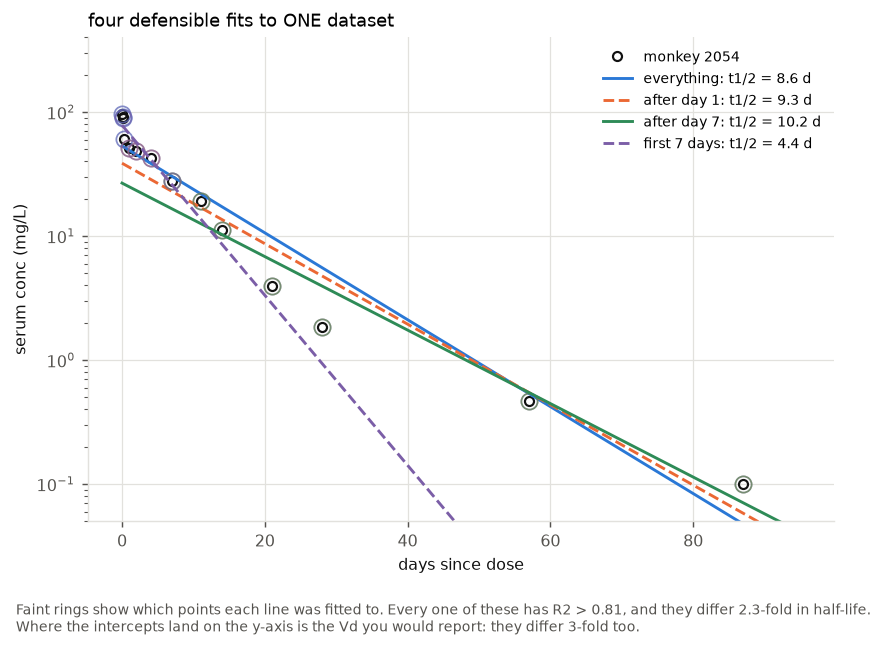

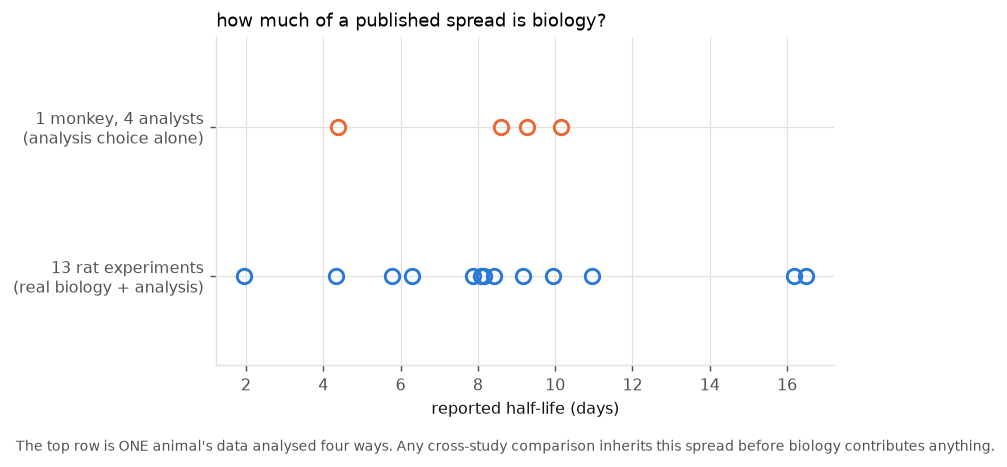

'/home/user/chiu__2022_rerun/tk_learning/figures/03_spread.png'

In [6]:
# D1 -- THE plot of this lesson. Four defensible choices of which points
# to fit, four different published half-lives, all on the same data.
fig, ax = plt.subplots(figsize=(6.4, 4.4), constrained_layout=True)
P.data_points(ax, one.time_d, one.conc_mgL, label="monkey 2054")
grid = np.linspace(0, 95, 300)
for (label, sel), col, ls in zip(
        [("everything", one.time_d >= 0), ("after day 1", one.time_d >= 1),
         ("after day 7", one.time_d >= 7), ("first 7 days", one.time_d <= 7)],
        P.CYCLE, ["-", "--", "-", "--"]):
    d = one[sel]
    kk, C0, _ = loglinear(d.time_d, d.conc_mgL)
    ax.plot(grid, C0 * np.exp(-kk * grid), ls, color=col, lw=1.6,
            label=f"{label}: t1/2 = {half_life(kk):.1f} d")
    # mark which points that line was actually fitted to
    ax.plot(d.time_d, d.conc_mgL, "o", color=col, ms=9, mfc="none",
            mew=0.9, alpha=0.5)
ax.set(yscale="log", ylim=(0.05, 400), xlabel="days since dose",
       ylabel="serum conc (mg/L)")
ax.set_title("four defensible fits to ONE dataset")
ax.legend(loc="upper right")
P.save(fig, "03_which_points.png",
       "Faint rings show which points each line was fitted to. Every one "
       "of these has R2 > 0.81, and they differ 2.3-fold in half-life.\n"
       "Where the intercepts land on the y-axis is the Vd you would "
       "report: they differ 3-fold too.")

# D2 -- the same four fits as a spread of half-lives, next to the spread
# across the 13 rat experiments. Two very different sources of variation.
fig, ax = plt.subplots(figsize=(6.4, 3.2), constrained_layout=True)
choices = []
for label, sel in [("everything", one.time_d >= 0), ("after day 1", one.time_d >= 1),
                   ("after day 7", one.time_d >= 7), ("first 7 days", one.time_d <= 7)]:
    kk, _, _ = loglinear(one[sel].time_d, one[sel].conc_mgL)
    choices.append(half_life(kk))
ax.plot(choices, [1] * len(choices), "o", color=P.ORANGE, ms=8, mfc="none", mew=1.6)
ax.plot(hl, [0] * len(hl), "o", color=P.BLUE, ms=8, mfc="none", mew=1.6)
ax.set_yticks([0, 1], ["13 rat experiments\n(real biology + analysis)",
                       "1 monkey, 4 analysts\n(analysis choice alone)"])
ax.set(xlabel="reported half-life (days)", ylim=(-0.6, 1.6))
ax.set_title("how much of a published spread is biology?")
P.save(fig, "03_spread.png",
       "The top row is ONE animal's data analysed four ways. Any "
       "cross-study comparison inherits this spread before biology "
       "contributes anything.")

### Questions

1. Why is the Vd you get from the terminal intercept too LARGE rather than too small? Sketch the two lines on a log axis.
1. Section A shows R2 near 1 for several different answers. What does that tell you about R2 as a check on a PK fit?
1. If a study sampled for only 7 days, would it report a half-life that is too short or too long? Which way would that bias a species comparison, given that human studies run for years?
1. Log-linear regression silently drops any point with C <= 0 (below the detection limit). Those are always the LATE points. What does that do to the estimated half-life?

### Exercises

1. Rerun section C with cut = t_max/2 and cut = t_max/5. How much do the half-lives move? That movement is the judgement call, quantified.
1. Compute the half-life for each of the three monkeys separately. How much do individuals differ? Compare that spread to the spread across rat experiments in section C.